In [4]:
# =========================================================================
# DATA EXPLORATION: VERIFYING EXACT SEGMENTATION CLASSES
# =========================================================================
import os
import nibabel as nib
import numpy as np

# Adjust this if your Kaggle path is different
BRATS_DIR = '/kaggle/input/datasets/i212385nomanarif/2024-brats-glioma'

# Get the first 5 patient folders
patient_folders = sorted([
    f for f in os.listdir(BRATS_DIR) 
    if os.path.isdir(os.path.join(BRATS_DIR, f))
])[:5] 

print("Scanning the first 5 patients to verify exact class labels...\n")

global_unique_classes = set()

for pat_id in patient_folders:
    seg_path = os.path.join(BRATS_DIR, pat_id, f'{pat_id}-seg.nii')
    
    if not os.path.exists(seg_path):
        print(f"[{pat_id}] Error: seg.nii not found!")
        continue
        
    # Load the 3D mask
    mask_data = nib.load(seg_path).get_fdata().astype(int)
    
    # Find unique pixel values and count them
    unique_vals, counts = np.unique(mask_data, return_counts=True)
    
    print(f"Patient: {pat_id}")
    for val, count in zip(unique_vals, counts):
        # Format the output so it's easy to read
        print(f"  ➔ Class {val}: {count:>10,} voxels")
        global_unique_classes.add(val)
    print("-" * 40)

print(f"\n✅ FINAL VERIFICATION: The exact classes found in these files are: {sorted(list(global_unique_classes))}")

Scanning the first 5 patients to verify exact class labels...

Patient: BraTS-GLI-00005-100
  ➔ Class 0:  7,193,826 voxels
  ➔ Class 2:     22,960 voxels
  ➔ Class 4:      4,246 voxels
----------------------------------------
Patient: BraTS-GLI-00005-101
  ➔ Class 0:  7,193,733 voxels
  ➔ Class 2:     23,658 voxels
  ➔ Class 4:      3,641 voxels
----------------------------------------
Patient: BraTS-GLI-00006-100
  ➔ Class 0:  7,181,051 voxels
  ➔ Class 2:     17,907 voxels
  ➔ Class 4:     22,074 voxels
----------------------------------------
Patient: BraTS-GLI-00006-101
  ➔ Class 0:  7,183,794 voxels
  ➔ Class 2:     18,747 voxels
  ➔ Class 4:     18,491 voxels
----------------------------------------
Patient: BraTS-GLI-00008-100
  ➔ Class 0:  7,212,105 voxels
  ➔ Class 2:      6,976 voxels
  ➔ Class 3:        135 voxels
  ➔ Class 4:      1,816 voxels
----------------------------------------

✅ FINAL VERIFICATION: The exact classes found in these files are: [np.int64(0), np.int64(2

In [5]:
# =========================================================================
# PHASE 1: ENVIRONMENT SETUP & DATA INGESTION
# Project: BraTS 2024 Post-Treatment 3D Segmentation (SwinUNETR)
# =========================================================================

# Install Medical Open Network for AI (MONAI) and dependencies
!pip install -q "monai[all]"
!pip install -q einops nibabel 

print("✓ CELL 1 COMPLETE: Medical frameworks and tensor libraries installed.")

✓ CELL 1 COMPLETE: Medical frameworks and tensor libraries installed.


In [6]:
# =========================================================================
# CELL 2: CORE IMPORTS AND GPU VERIFICATION
# =========================================================================
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# Core MONAI utilities
from monai.data import Dataset, DataLoader
from monai.utils import set_determinism

# Enforce deterministic behavior for reproducibility
set_determinism(seed=42)
torch.manual_seed(42)

# Hardware allocation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("✓ CELL 2 COMPLETE: Core libraries imported.")
print(f"➔ Compute Backend: {device}")
if torch.cuda.is_available():
    print(f"➔ Active GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True # Optimizes 3D convolutional speeds

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-06-02 04:53:02.353129: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780375982.583490     378 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780375982.643943     378 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780375983.184962     378 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780375983.184998     378 computation_placer.cc:1

✓ CELL 2 COMPLETE: Core libraries imported.
➔ Compute Backend: cuda
➔ Active GPU: Tesla T4


In [7]:
# =========================================================================
# CELL 3: VOLUMETRIC DATASET PARSING & DICTIONARY MAPPING
# =========================================================================
# The absolute path to your dataset in Kaggle
DATASET_PATH = '/kaggle/input/datasets/i212385nomanarif/2024-brats-glioma'

# Gather all patient sub-directories
subject_dirs = sorted([
    d for d in os.listdir(DATASET_PATH) 
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

dataset_dicts = []
missing_files_count = 0

print("Scanning dataset directory and mapping modalities...")

for sub_id in subject_dirs:
    sub_root = os.path.join(DATASET_PATH, sub_id)
    
    # Map the 4 input modalities and 1 target mask
    modality_map = {
        "t1n": os.path.join(sub_root, f"{sub_id}-t1n.nii"),
        "t1c": os.path.join(sub_root, f"{sub_id}-t1c.nii"),
        "t2f": os.path.join(sub_root, f"{sub_id}-t2f.nii"),
        "t2w": os.path.join(sub_root, f"{sub_id}-t2w.nii"),
        "seg": os.path.join(sub_root, f"{sub_id}-seg.nii")
    }
    
    # Only append if all 5 files exist to prevent runtime crashes later
    if all(os.path.exists(path) for path in modality_map.values()):
        dataset_dicts.append(modality_map)
    else:
        missing_files_count += 1

print("\n✓ CELL 3 COMPLETE: Dataset dictionaries compiled.")
print(f"➔ Total Valid Patients Mapped: {len(dataset_dicts)}")
print(f"➔ Patients Skipped (Missing Data): {missing_files_count}")

# Verify the structure of the first patient
if len(dataset_dicts) > 0:
    print("\nData mapping example for Patient 0:")
    for key, val in dataset_dicts[0].items():
        print(f"  [{key.upper()}] -> {val.split('/')[-1]}")

Scanning dataset directory and mapping modalities...

✓ CELL 3 COMPLETE: Dataset dictionaries compiled.
➔ Total Valid Patients Mapped: 700
➔ Patients Skipped (Missing Data): 0

Data mapping example for Patient 0:
  [T1N] -> BraTS-GLI-00005-100-t1n.nii
  [T1C] -> BraTS-GLI-00005-100-t1c.nii
  [T2F] -> BraTS-GLI-00005-100-t2f.nii
  [T2W] -> BraTS-GLI-00005-100-t2w.nii
  [SEG] -> BraTS-GLI-00005-100-seg.nii


In [8]:
# =========================================================================
# PHASE 2: THE 3D MONAI PROCESSING PIPELINE
# CELL 4: TRANFORMS DEFINITION AND ET-COMPLIANT LABEL MAPPER
# =========================================================================
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ConcatItemsd,
    NormalizeIntensityd,
    RandCropByPosNegLabeld,
    MapTransform
)

class CleanBraTSLabelsd(MapTransform):
    """
    Custom MONAI Transform to map raw non-contiguous labels to continuous indices.
    Raw BraTS: 0 (BG), 2 (SNFH Swelling), 3 (ET Active Tumor), 4 (RC Cavity)
    Target PyTorch: 0, 1, 2, 3
    """
    def __init__(self, keys):
        super().__init__(keys)

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            mask = d[key]
            # Create an optimized output matrix matching the tensor type
            cleaned_mask = torch.zeros_like(mask)
            
            cleaned_mask[mask == 2] = 1  # Swelling / SNFH
            cleaned_mask[mask == 3] = 2  # Active Tumor / ET
            cleaned_mask[mask == 4] = 3  # Resection Cavity / RC
            
            d[key] = cleaned_mask
        return d

# Define the training transforms
train_transforms = Compose([
    # 1. Load the 3D NIfTI volumes
    LoadImaged(keys=["t1n", "t1c", "t2f", "t2w", "seg"]),
    # 2. Add the channel dimension [Channels, H, W, D]
    EnsureChannelFirstd(keys=["t1n", "t1c", "t2f", "t2w", "seg"]),
    # 3. Combine the 4 structural MRI sequences into a 4-channel input tensor
    ConcatItemsd(keys=["t1n", "t1c", "t2f", "t2w"], name="image"),
    # 4. Map labels cleanly to [0, 1, 2, 3]
    CleanBraTSLabelsd(keys=["seg"]),
    # 5. Normalize intensity across the channels
    NormalizeIntensityd(keys=["image"]),
    # 6. Dynamically extract a 3D crop centered around tumor regions
    RandCropByPosNegLabeld(
        keys=["image", "seg"],
        label_key="seg",
        spatial_size=(96, 96, 96),
        pos=1,
        neg=1,
        num_samples=1,
    )
])

# Define validation transforms (no random cropping anomalies)
val_transforms = Compose([
    LoadImaged(keys=["t1n", "t1c", "t2f", "t2w", "seg"]),
    EnsureChannelFirstd(keys=["t1n", "t1c", "t2f", "t2w", "seg"]),
    ConcatItemsd(keys=["t1n", "t1c", "t2f", "t2w"], name="image"),
    CleanBraTSLabelsd(keys=["seg"]),
    NormalizeIntensityd(keys=["image"])
])

print("✓ CELL 4 COMPLETE: 4-Class MONAI processing pipelines compiled.")

✓ CELL 4 COMPLETE: 4-Class MONAI processing pipelines compiled.


In [9]:
# =========================================================================
# CELL 5: GENERATING EXPERIMENTAL SPLITS AND 3D DATALOADERS
# =========================================================================

# Determine training and validation split counts
num_total = len(dataset_dicts)
num_train = int(0.8 * num_total)
num_val = num_total - num_train

train_files = dataset_dicts[:num_train]
val_files = dataset_dicts[num_train:]

# Instantiate optimized MONAI datasets
train_ds = Dataset(data=train_files, transform=train_transforms)
val_ds = Dataset(data=val_files, transform=val_transforms)

# Build high-throughput dataloaders
train_loader = DataLoader(
    train_ds, 
    batch_size=1, # 3D volumes require small batch sizes to prevent GPU Out-of-Memory
    shuffle=True, 
    num_workers=2, 
    pin_memory=True
)

val_loader = DataLoader(
    val_ds, 
    batch_size=1, 
    shuffle=False, 
    num_workers=2, 
    pin_memory=True
)

print("✓ CELL 5 COMPLETE: Data split complete.")
print(f"➔ Training Patients Data Queued: {len(train_files)}")
print(f"➔ Validation Patients Data Queued: {len(val_files)}")

✓ CELL 5 COMPLETE: Data split complete.
➔ Training Patients Data Queued: 560
➔ Validation Patients Data Queued: 140


In [10]:
# =========================================================================
# CELL 6: SANITY CHECK ON TENSOR SHAPES
# =========================================================================
print("Extracting sample batch from pipeline...")
sample_batch = next(iter(train_loader))

image_shape = sample_batch["image"].shape
label_shape = sample_batch["seg"].shape

print("\n✓ CELL 6 CONFIGURATION CHECK SUCCESSFUL:")
print(f"➔ Stacked Input Tensor Shape (Image): {image_shape} -> [Batch, Channels, H, W, D]")
print(f"➔ Ground Truth Target Shape (Mask) : {label_shape} -> [Batch, Channels, H, W, D]")

# Verify spatial compatibility
if image_shape[1] == 4 and label_shape[1] == 1:
    print("\n✅ Dimension alignment verified! The data is perfectly structured for Phase 3.")
else:
    print("\n⚠ Warning: Dimensional anomaly detected. Re-verify channel inputs.")

Extracting sample batch from pipeline...

✓ CELL 6 CONFIGURATION CHECK SUCCESSFUL:
➔ Stacked Input Tensor Shape (Image): torch.Size([1, 4, 96, 96, 96]) -> [Batch, Channels, H, W, D]
➔ Ground Truth Target Shape (Mask) : torch.Size([1, 1, 96, 96, 96]) -> [Batch, Channels, H, W, D]

✅ Dimension alignment verified! The data is perfectly structured for Phase 3.


Extracting a sample batch from the 3D pipeline...
➔ Input Tensor Shape: torch.Size([4, 96, 96, 96])
➔ Mask Tensor Shape:  torch.Size([96, 96, 96])
➔ Visualizing Z-Axis Depth: 66 (Slice with maximum pathology)


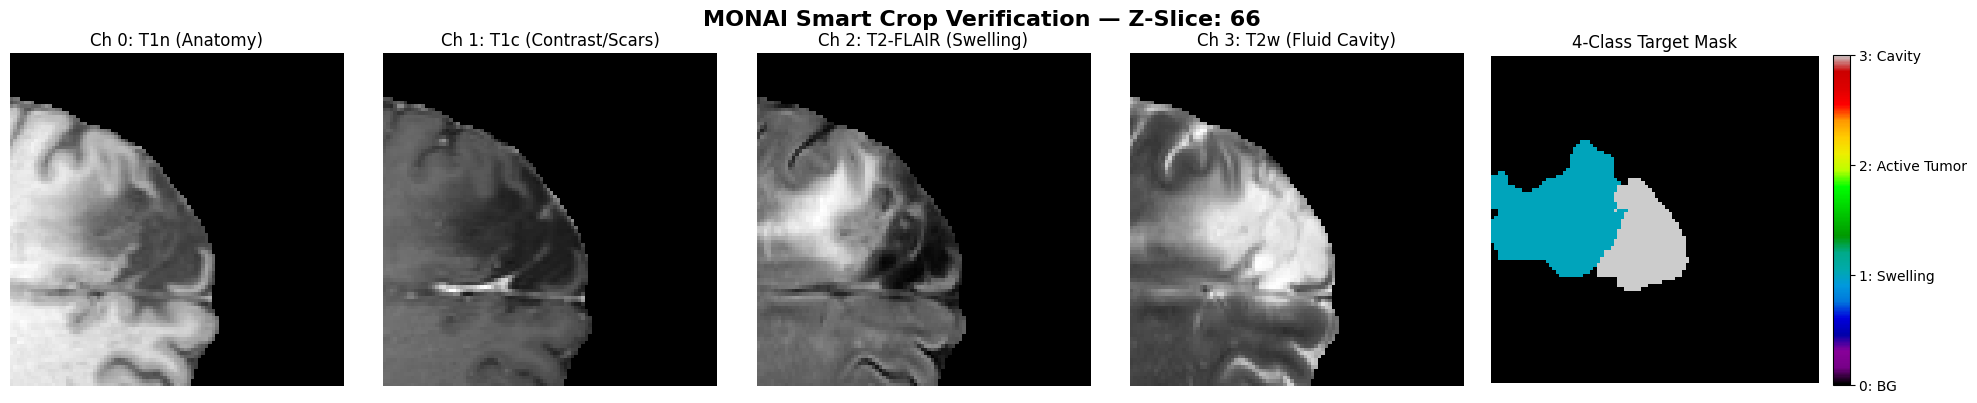


✅ Visual proof generated. The 4 modalities are aligned, and the mask contains mapped integers.


In [11]:
# =========================================================================
# CELL 6: VISUALIZING THE 3D PIPELINE OUTPUT (PROOF OF CROP & ALIGNMENT)
# =========================================================================
import matplotlib.pyplot as plt
import torch

print("Extracting a sample batch from the 3D pipeline...")
sample_batch = next(iter(train_loader))

# Extract the tensors [Batch, Channel, X, Y, Z]
image_tensor = sample_batch["image"][0] # Shape: [4, 96, 96, 96]
mask_tensor = sample_batch["seg"][0][0] # Shape: [96, 96, 96]

print(f"➔ Input Tensor Shape: {image_tensor.shape}")
print(f"➔ Mask Tensor Shape:  {mask_tensor.shape}")

# To prove the crop worked, we need to find a slice in the Z-axis that actually has a tumor.
# We scan the Z-axis and find the index with the maximum number of pathology voxels (>0)
z_slice_counts = [torch.sum(mask_tensor[:, :, z] > 0).item() for z in range(mask_tensor.shape[2])]
best_z_slice = z_slice_counts.index(max(z_slice_counts))

print(f"➔ Visualizing Z-Axis Depth: {best_z_slice} (Slice with maximum pathology)")

# Set up the visualization grid
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle(f"MONAI Smart Crop Verification — Z-Slice: {best_z_slice}", fontsize=16, fontweight='bold')

# 1. T1n (Anatomy)
axes[0].imshow(image_tensor[0, :, :, best_z_slice].cpu().numpy(), cmap="gray")
axes[0].set_title("Ch 0: T1n (Anatomy)")
axes[0].axis('off')

# 2. T1c (Active Tumor/Scars)
axes[1].imshow(image_tensor[1, :, :, best_z_slice].cpu().numpy(), cmap="gray")
axes[1].set_title("Ch 1: T1c (Contrast/Scars)")
axes[1].axis('off')

# 3. T2f (Swelling)
axes[2].imshow(image_tensor[2, :, :, best_z_slice].cpu().numpy(), cmap="gray")
axes[2].set_title("Ch 2: T2-FLAIR (Swelling)")
axes[2].axis('off')

# 4. T2w (Fluid)
axes[3].imshow(image_tensor[3, :, :, best_z_slice].cpu().numpy(), cmap="gray")
axes[3].set_title("Ch 3: T2w (Fluid Cavity)")
axes[3].axis('off')

# 5. The 4-Class Ground Truth Mask
# Using a colormap that clearly separates the 4 integer values [0, 1, 2, 3]
mask_plot = axes[4].imshow(mask_tensor[:, :, best_z_slice].cpu().numpy(), cmap="nipy_spectral", vmin=0, vmax=3)
axes[4].set_title("4-Class Target Mask")
axes[4].axis('off')

# Add a legend for the mask
cbar = fig.colorbar(mask_plot, ax=axes[4], ticks=[0, 1, 2, 3], fraction=0.046, pad=0.04)
cbar.ax.set_yticklabels(['0: BG', '1: Swelling', '2: Active Tumor', '3: Cavity'])

plt.tight_layout()
plt.show()

print("\n✅ Visual proof generated. The 4 modalities are aligned, and the mask contains mapped integers.")

In [12]:
# =========================================================================
# PHASE 3: ARCHITECTURE AND CORE TRAINING
# CELL 7: INITIALIZING SWIN-UNETR AND DICE OPTIMIZATION (UPDATED)
# =========================================================================
from monai.networks.nets import SwinUNETR
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
import torch

print("Initializing 3D SwinUNETR Architecture...")

# 1. The Model Architecture
model = SwinUNETR(
    spatial_dims=3,        # Tells MONAI we are doing 3D (Replaces img_size)
    in_channels=4,         # T1n, T1c, T2f, T2w
    out_channels=4,        # 0=BG, 1=Swelling, 2=Active Tumor, 3=Cavity
    feature_size=24,       # Optimized for 16GB Kaggle GPU constraints
    drop_rate=0.2,         # Active dropout (We need this later for Monte Carlo!)
    attn_drop_rate=0.1,
    dropout_path_rate=0.1
).to(device)

# 2. The Loss Function (Dice Loss)
loss_function = DiceLoss(
    to_onehot_y=True, 
    softmax=True, 
    include_background=False
)

# 3. Optimizer and Learning Rate Scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# 4. Evaluation Metric
dice_metric = DiceMetric(include_background=False, reduction="mean")

print("✓ CELL 7 COMPLETE: Architecture, Loss, and Optimizers are locked in.")

Initializing 3D SwinUNETR Architecture...
✓ CELL 7 COMPLETE: Architecture, Loss, and Optimizers are locked in.


In [ ]:
# =========================================================================
# CELL 8: THE CORE TRAINING LOOP
# =========================================================================
from monai.inferers import sliding_window_inference
from monai.transforms import AsDiscrete
from monai.data import decollate_batch

# Kaggle Training Parameters
MAX_EPOCHS = 10 # Set to 10 for initial proof-of-concept. Increase to 50+ for final paper.
VAL_INTERVAL = 2 # Check accuracy every 2 epochs
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

# Post-processing transforms to convert raw model probabilities into hard integer predictions
post_pred = AsDiscrete(argmax=True, to_onehot=4)
post_label = AsDiscrete(to_onehot=4)

print(f"🚀 IGNITING TRAINING PIPELINE: Running for {MAX_EPOCHS} Epochs...")

for epoch in range(MAX_EPOCHS):
    print("-" * 30)
    print(f"Epoch {epoch + 1}/{MAX_EPOCHS}")
    
    # --- TRAINING PHASE ---
    model.train()
    epoch_loss = 0
    step = 0
    
    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data["image"].to(device), batch_data["seg"].to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        # Print progress every 50 batches
        if step % 50 == 0:
            print(f"  [Train] Step {step}/{len(train_loader)} - Batch Loss: {loss.item():.4f}")
            
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"➔ Average Epoch Loss: {epoch_loss:.4f}")
    
    # --- VALIDATION PHASE (Check accuracy on unseen data) ---
    if (epoch + 1) % VAL_INTERVAL == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = val_data["image"].to(device), val_data["seg"].to(device)
                
                # Sliding window inference is required because validation images are full size, not cropped!
                val_outputs = sliding_window_inference(
                    val_inputs, roi_size=(96, 96, 96), sw_batch_size=2, predictor=model
                )
                
                # Deconstruct the batch and apply discrete conversions
                val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]
                val_labels = [post_label(i) for i in decollate_batch(val_labels)]
                
                # Compute accuracy
                dice_metric(y_pred=val_outputs, y=val_labels)
                
            # Aggregate the final score
            metric = dice_metric.aggregate().item()
            dice_metric.reset()
            metric_values.append(metric)
            
            print(f"➔ Validation Dice Score: {metric:.4f}")
            
            # AUTO-SAVE: If the model beat its previous best, save the weights!
            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), "best_swinunetr_model.pth")
                print(f"  [!] New Best Model Saved! (Score: {best_metric:.4f})")

print("-" * 30)
print(f"🏁 TRAINING COMPLETE! Best validation score: {best_metric:.4f} at epoch {best_metric_epoch}")

🚀 IGNITING TRAINING PIPELINE: Running for 10 Epochs...
------------------------------
Epoch 1/10
  [Train] Step 50/560 - Batch Loss: 0.9231
  [Train] Step 100/560 - Batch Loss: 0.8463
  [Train] Step 150/560 - Batch Loss: 0.7913
  [Train] Step 200/560 - Batch Loss: 0.8544
  [Train] Step 250/560 - Batch Loss: 0.7609
  [Train] Step 300/560 - Batch Loss: 0.7252
  [Train] Step 350/560 - Batch Loss: 0.7552
  [Train] Step 400/560 - Batch Loss: 0.9302
  [Train] Step 450/560 - Batch Loss: 0.7356
  [Train] Step 500/560 - Batch Loss: 0.9656
  [Train] Step 550/560 - Batch Loss: 0.8150
➔ Average Epoch Loss: 0.8482
------------------------------
Epoch 2/10
  [Train] Step 50/560 - Batch Loss: 0.8260
  [Train] Step 100/560 - Batch Loss: 0.7053
  [Train] Step 150/560 - Batch Loss: 0.9513
  [Train] Step 200/560 - Batch Loss: 0.7923
  [Train] Step 250/560 - Batch Loss: 0.8063
  [Train] Step 300/560 - Batch Loss: 0.8810
  [Train] Step 350/560 - Batch Loss: 0.9780
  [Train] Step 400/560 - Batch Loss: 0.664

Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)


➔ Validation Dice Score: 0.1798
  [!] New Best Model Saved! (Score: 0.1798)
------------------------------
Epoch 3/10
  [Train] Step 50/560 - Batch Loss: 0.5212
  [Train] Step 100/560 - Batch Loss: 0.7294
  [Train] Step 150/560 - Batch Loss: 1.0000
  [Train] Step 200/560 - Batch Loss: 0.9935
  [Train] Step 250/560 - Batch Loss: 0.9999
  [Train] Step 300/560 - Batch Loss: 0.8645
  [Train] Step 350/560 - Batch Loss: 0.9556
  [Train] Step 400/560 - Batch Loss: 0.7550
  [Train] Step 450/560 - Batch Loss: 1.0000
  [Train] Step 500/560 - Batch Loss: 0.7123
  [Train] Step 550/560 - Batch Loss: 0.4846
➔ Average Epoch Loss: 0.7342
------------------------------
Epoch 4/10
  [Train] Step 50/560 - Batch Loss: 1.0000
  [Train] Step 100/560 - Batch Loss: 0.6211
  [Train] Step 150/560 - Batch Loss: 0.4318
  [Train] Step 200/560 - Batch Loss: 0.3498
  [Train] Step 250/560 - Batch Loss: 0.6491
  [Train] Step 300/560 - Batch Loss: 1.0000
  [Train] Step 350/560 - Batch Loss: 0.6336
  [Train] Step 400/56